# PPO vs DQN Solaris Comparison

This notebook loads the DQN baseline time-series data from `challenge3__<5>/time_series/dqn` and the PPO experiment data from `challenge3__<5>/time_series/ppo`. It computes sample efficiency, final performance, and training stability, then generates comparison plots for the learning curves.

In [1]:
import csv
import os
import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd()
root = cwd
while not (root / 'time_series').exists() and root != root.parent:
    root = root.parent
if not (root / 'time_series').exists():
    raise FileNotFoundError('Could not locate the challenge3__<5>/time_series directory from the current working directory.')
DATA_ROOT = root / 'time_series'
DQN_ROOT = DATA_ROOT / 'dqn' / 'rew_mean'
PPO_ROOT = DATA_ROOT / 'ppo' / 'mean_return'
OUTPUT_DIR = cwd / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def load_csv_series(csv_path):
    steps = []
    values = []
    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                steps.append(float(row['Step']))
                values.append(float(row['Value']))
            except KeyError:
                raise KeyError(f'Missing expected column in {csv_path}')
    return np.array(steps, dtype=float), np.array(values, dtype=float)

def load_replicates(root_dir):
    replicates = {}
    for path in sorted(root_dir.glob('*.csv')):
        name = path.stem
        steps, values = load_csv_series(path)
        replicates[name] = {'path': path, 'steps': steps, 'values': values}
    return replicates

def auc_normalized(steps, values):
    if len(steps) < 2:
        return 0.0
    area = np.trapz(values, steps)
    total = steps[-1] - steps[0] if steps[-1] > steps[0] else 1.0
    return area / total

def threshold_step(steps, values, threshold):
    for s, v in zip(steps, values):
        if v >= threshold:
            return s
    return math.inf

In [2]:
dqn_reps = load_replicates(DQN_ROOT)
ppo_reps = load_replicates(PPO_ROOT)

print(f'Found {len(dqn_reps)} DQN replicates and {len(ppo_reps)} PPO replicates.')
print('DQN files:')
for key in dqn_reps:
    print(' -', key)
print('PPO files:')
for key in ppo_reps:
    print(' -', key)

Found 3 DQN replicates and 3 PPO replicates.
DQN files:
 - optuna_tpe_best(2M TIMESTEPS 3 seeds experiment)_replicate_1_DQN_1 rew_mean
 - optuna_tpe_best(2M TIMESTEPS 3 seeds experiment)_replicate_2_DQN_1 rew_mean
 - optuna_tpe_best(2M TIMESTEPS 3 seeds experiment)_replicate_3_DQN_1 rew_mean
PPO files:
 - replicates_ppo_solaris_gae_variance_reduction (Final choose model) 3 seeds expirment_replicate_1_ppo_solaris_gae_variance_reduction (Final choose model) 3 seeds expirment_replicate_1_seed_52372_1778811463 mean_return
 - replicates_ppo_solaris_gae_variance_reduction (Final choose model) 3 seeds expirment_replicate_2_ppo_solaris_gae_variance_reduction (Final choose model) 3 seeds expirment_replicate_2_seed_66064_1778823565 mean_return
 - replicates_ppo_solaris_gae_variance_reduction (Final choose model) 3 seeds expirment_replicate_3_ppo_solaris_gae_variance_reduction (Final choose model) 3 seeds expirment_replicate_3_seed_95921_1778835688 mean_return


In [6]:
print('=== Comparison Metrics ===')
print(f'Threshold for sample efficiency: {baseline_threshold:.2f}')
print('DQN final performance mean/std:', f"{results['dqn']['final_mean']:.2f}", f"{results['dqn']['final_std']:.2f}")
print('PPO final performance mean/std:', f"{results['ppo']['final_mean']:.2f}", f"{results['ppo']['final_std']:.2f}")
print('DQN normalized AUC mean:', f"{results['dqn']['stability_auc_norm']:.2f}")
print('PPO normalized AUC mean:', f"{results['ppo']['stability_auc_norm']:.2f}")
print('DQN sample efficiency steps:', results['dqn']['sample_efficiency_steps'])
print('PPO sample efficiency steps:', results['ppo']['sample_efficiency_steps'])


=== Comparison Metrics ===


NameError: name 'baseline_threshold' is not defined

Saved comparison plot to /home/vydi/ML Challenges/challenge3__<5>/variance_analysis/figures/ppo_vs_dqn_learning_curve.png


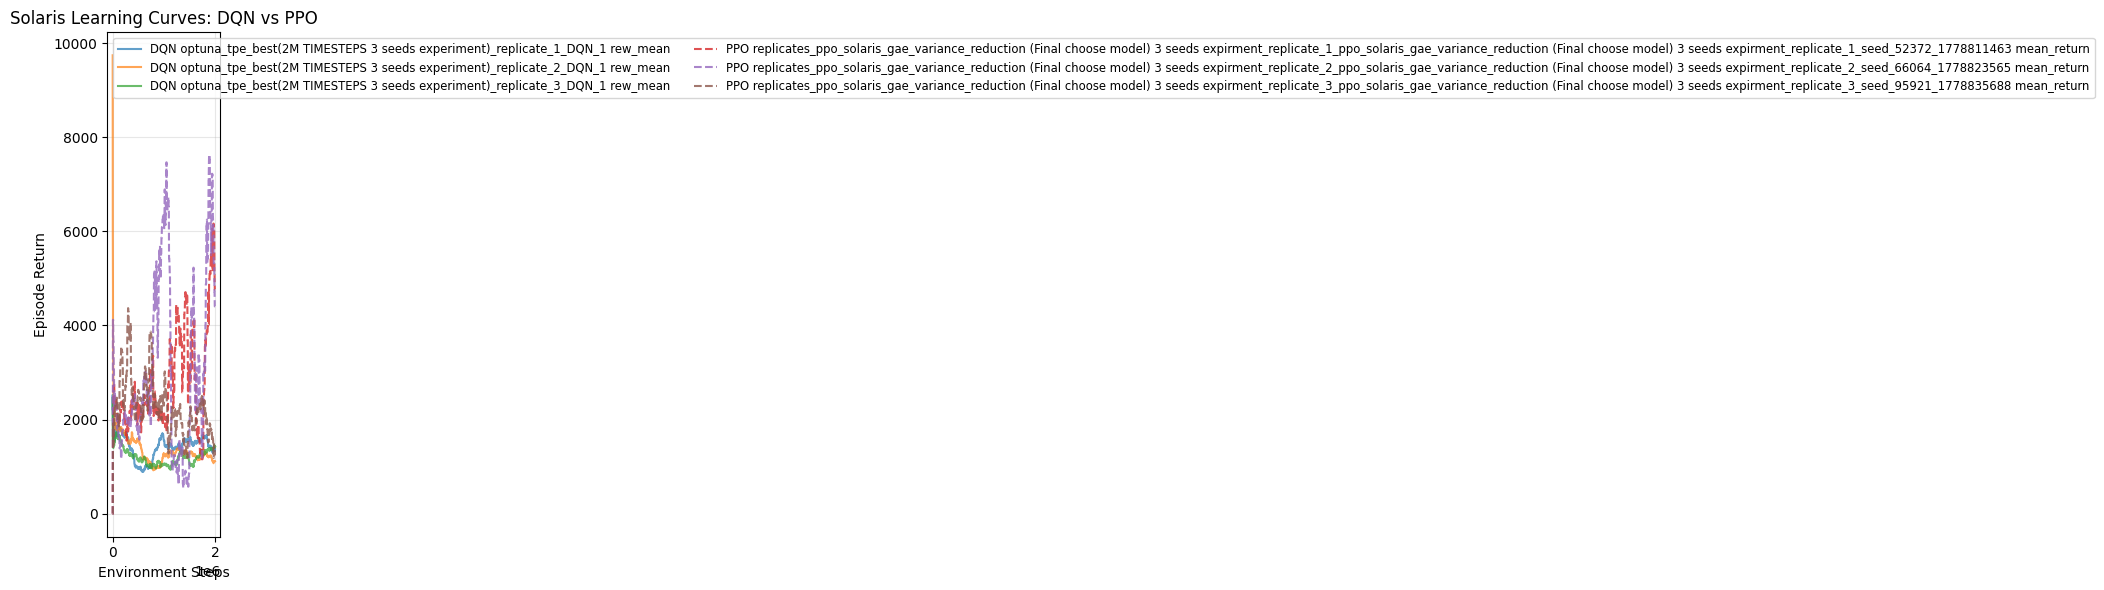

In [4]:
plt.figure(figsize=(12, 6))
for name, rep in dqn_reps.items():
    plt.plot(rep['steps'], rep['values'], label=f'DQN {name}', alpha=0.7)
for name, rep in ppo_reps.items():
    plt.plot(rep['steps'], rep['values'], label=f'PPO {name}', linestyle='--', alpha=0.8)

plt.title('Solaris Learning Curves: DQN vs PPO')
plt.xlabel('Environment Steps')
plt.ylabel('Episode Return')
plt.legend(fontsize='small', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
figure_path = OUTPUT_DIR / 'ppo_vs_dqn_learning_curve.png'
plt.savefig(figure_path, dpi=200)
print(f'Saved comparison plot to {figure_path}')
plt.show()

In [5]:
import json
metrics_path = Path('ppo_vs_dqn_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved metrics summary to {metrics_path}')

# Optionally save a human-readable CSV summary for easy review
csv_path = Path('ppo_vs_dqn_metrics_summary.csv')
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['group', 'final_mean', 'final_std', 'stability_auc_norm', 'sample_efficiency_steps'])
    writer.writerow(['DQN', results['dqn']['final_mean'], results['dqn']['final_std'], results['dqn']['stability_auc_norm'], ' | '.join(str(x) for x in results['dqn']['sample_efficiency_steps'])])
    writer.writerow(['PPO', results['ppo']['final_mean'], results['ppo']['final_std'], results['ppo']['stability_auc_norm'], ' | '.join(str(x) for x in results['ppo']['sample_efficiency_steps'])])
print(f'Saved CSV summary to {csv_path}')

NameError: name 'results' is not defined